In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [126]:

url = "https://raw.githubusercontent.com/mpolinowski/hotel-booking-dataset/master/datasets/hotel_bookings.csv"

df = pd.read_csv(url)

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [128]:
all_column = df.columns
all_column

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [129]:
len(df.columns)

32

In [167]:
num_Column = df.select_dtypes(include= ['int64',"float64"]).columns
categorical_Column = df.select_dtypes(include= "object").columns

/var/folders/qp/mnlhrt5x2rx27zstwr3s8_200000gp/T/ipykernel_1873/1089981631.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_Column = df.select_dtypes(include= "object").columns


In [165]:
num_Column

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='str')

In [168]:
categorical_Column

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='str')

In [130]:
df. head(4)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15


In [131]:
df.shape

(119390, 32)

In [132]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [133]:
for i in all_column :
    print(f'{i} have :  {df[i].nunique()} unique values ')
    

hotel have :  2 unique values 
is_canceled have :  2 unique values 
lead_time have :  479 unique values 
arrival_date_year have :  3 unique values 
arrival_date_month have :  12 unique values 
arrival_date_week_number have :  53 unique values 
arrival_date_day_of_month have :  31 unique values 
stays_in_weekend_nights have :  17 unique values 
stays_in_week_nights have :  35 unique values 
adults have :  14 unique values 
children have :  5 unique values 
babies have :  5 unique values 
meal have :  5 unique values 
country have :  177 unique values 
market_segment have :  8 unique values 
distribution_channel have :  5 unique values 
is_repeated_guest have :  2 unique values 
previous_cancellations have :  15 unique values 
previous_bookings_not_canceled have :  73 unique values 
reserved_room_type have :  10 unique values 
assigned_room_type have :  12 unique values 
booking_changes have :  21 unique values 
deposit_type have :  3 unique values 
agent have :  333 unique values 
compa

# data preprocessing

In [134]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

# Only columnns have nulls

In [135]:
for col in all_column: 
    if df[col].isna().sum() > 0 :
        print(f"{col} :{df[col].isna().sum()} nulls")


children :4 nulls
country :488 nulls
agent :16340 nulls
company :112593 nulls


In [136]:
df["children"].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: children, dtype: float64

In [137]:
df["children"] . max()

10.0

In [138]:
for i in range (11):
    print(f"have {i} chidren {(df["children"] == i ).sum()}  rows")


have 0 chidren 110796  rows
have 1 chidren 4861  rows
have 2 chidren 3652  rows
have 3 chidren 76  rows
have 4 chidren 0  rows
have 5 chidren 0  rows
have 6 chidren 0  rows
have 7 chidren 0  rows
have 8 chidren 0  rows
have 9 chidren 0  rows
have 10 chidren 1  rows


##### think that have 10 cheldren are outlier


In [141]:
df["children"] = df["children"].fillna(df["children"].mode()[0])

In [142]:
df["children"].isna().sum()

0

In [147]:
df.country.unique()

<ArrowStringArray>
['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA',   nan, 'ROU', 'NOR', 'OMN',
 ...
 'ATA', 'GTM', 'ASM', 'MRT', 'NCL', 'KIR', 'SDN', 'ATF', 'SLE', 'LAO']
Length: 178, dtype: str

In [149]:

df.country.value_counts()

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
NCL        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 177, dtype: int64

In [151]:
df["country"].mode()[0]

'PRT'

In [150]:
df.country.mode()

0    PRT
Name: country, dtype: str

In [153]:
df["country"]=df.country.fillna(df["country"].mode()[0])

In [155]:
df.country.isna().sum()

0

In [158]:
df.agent.unique()

array([ nan, 304., 240., 303.,  15., 241.,   8., 250., 115.,   5., 175.,
       134., 156., 243., 242.,   3., 105.,  40., 147., 306., 184.,  96.,
         2., 127.,  95., 146.,   9., 177.,   6., 143., 244., 149., 167.,
       300., 171., 305.,  67., 196., 152., 142., 261., 104.,  36.,  26.,
        29., 258., 110.,  71., 181.,  88., 251., 275.,  69., 248., 208.,
       256., 314., 126., 281., 273., 253., 185., 330., 334., 328., 326.,
       321., 324., 313.,  38., 155.,  68., 335., 308., 332.,  94., 348.,
       310., 339., 375.,  66., 327., 387., 298.,  91., 245., 385., 257.,
       393., 168., 405., 249., 315.,  75., 128., 307.,  11., 436.,   1.,
       201., 183., 223., 368., 336., 291., 464., 411., 481.,  10., 154.,
       468., 410., 390., 440., 495., 492., 493., 434.,  57., 531., 420.,
       483., 526., 472., 429.,  16., 446.,  34.,  78., 139., 252., 270.,
        47., 114., 301., 193., 182., 135., 350., 195., 352., 355., 159.,
       363., 384., 360., 331., 367.,  64., 406., 16

In [161]:
df.company.nunique()

352

In [159]:
df.agent.nunique()

333

In [169]:
df["has_agent"] = df["agent"].notna().astype(int)
df["has_company"] = df["company"].notna().astype(int)

df = df.drop(columns=["agent", "company"])

In [173]:
df.has_agent.value_counts()

has_agent
1    103050
0     16340
Name: count, dtype: int64

In [172]:
df.isna().sum().sum()

0

#####  children :4 nulls       >>> cleaned by filling by the mode
#####  country :488 nulls.     >>> cleaned by filling by the mode
#####  agent :16340 nulls.     >>> cleaned by (0 - 1 ) encoding that 1 has agent and 0 hasn't
#####  company :112593 nulls.  >>> cleaned by (0 - 1 ) encoding that 1 has company and 0 hasn't

## duplicates

In [176]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate rows: {duplicate_count}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate rows: 32030
Duplicate percentage: 26.83%


In [179]:
df.shape[0]

119390

In [180]:
df = df.drop_duplicates()

In [185]:
df_rows_now = df.shape[0] - 32030
df_rows_now

55330

In [186]:
df.duplicated().sum()

0

In [187]:
((df["adults"] + df["children"] + df["babies"]) == 0).sum()

166

In [189]:
not_logical_guests = ((df["adults"] + df["children"] + df["babies"]) == 0)

In [190]:
df[not_logical_guests]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_agent,has_company
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,0,Transient-Party,0.00,0,0,Check-Out,06-10-15,0,1
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,0,Transient,0.00,0,0,Check-Out,12-10-15,0,1
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,0,Transient-Party,0.00,0,0,Check-Out,23-11-15,1,0
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,122,Transient-Party,0.00,0,0,Check-Out,04-01-16,1,0
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,122,Transient-Party,0.00,0,0,Check-Out,05-01-16,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2017,June,26,27,0,3,0,...,No Deposit,0,Transient,100.80,0,0,Check-Out,30-06-17,1,0
115091,City Hotel,0,1,2017,June,26,30,0,1,0,...,No Deposit,0,Transient,0.00,1,1,Check-Out,01-07-17,0,0
116251,City Hotel,0,44,2017,July,28,15,1,1,0,...,No Deposit,0,Transient,73.80,0,0,Check-Out,17-07-17,1,0
116534,City Hotel,0,2,2017,July,28,15,2,5,0,...,No Deposit,0,Transient-Party,22.86,0,1,Check-Out,22-07-17,1,0


In [191]:
df = df[~not_logical_guests]

In [195]:
((df["adults"] + df["children"] + df["babies"]) == 0).sum()

0

In [199]:
df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

In [201]:
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

## train test split

In [202]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

In [206]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (69755, 33)
X_test: (17439, 33)
y_train: (69755,)
y_test: (17439,)


In [207]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

is_canceled
0    0.724708
1    0.275292
Name: proportion, dtype: float64
is_canceled
0    0.724698
1    0.275302
Name: proportion, dtype: float64


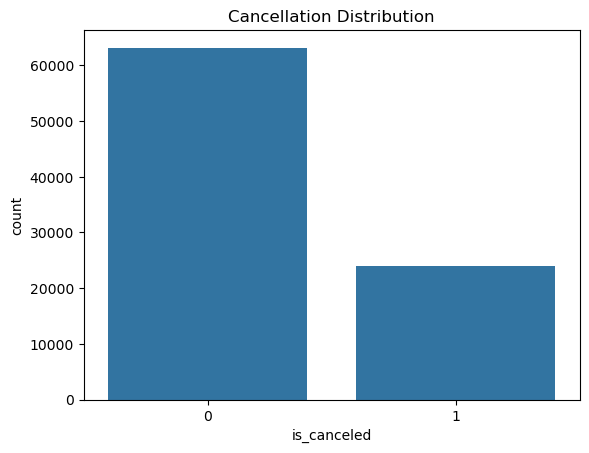

is_canceled
0    63190
1    24004
Name: count, dtype: int64
is_canceled
0    0.724706
1    0.275294
Name: proportion, dtype: float64


In [208]:

sns.countplot(x=y)
plt.title("Cancellation Distribution")
plt.show()
print(y.value_counts())
print(y.value_counts(normalize=True))

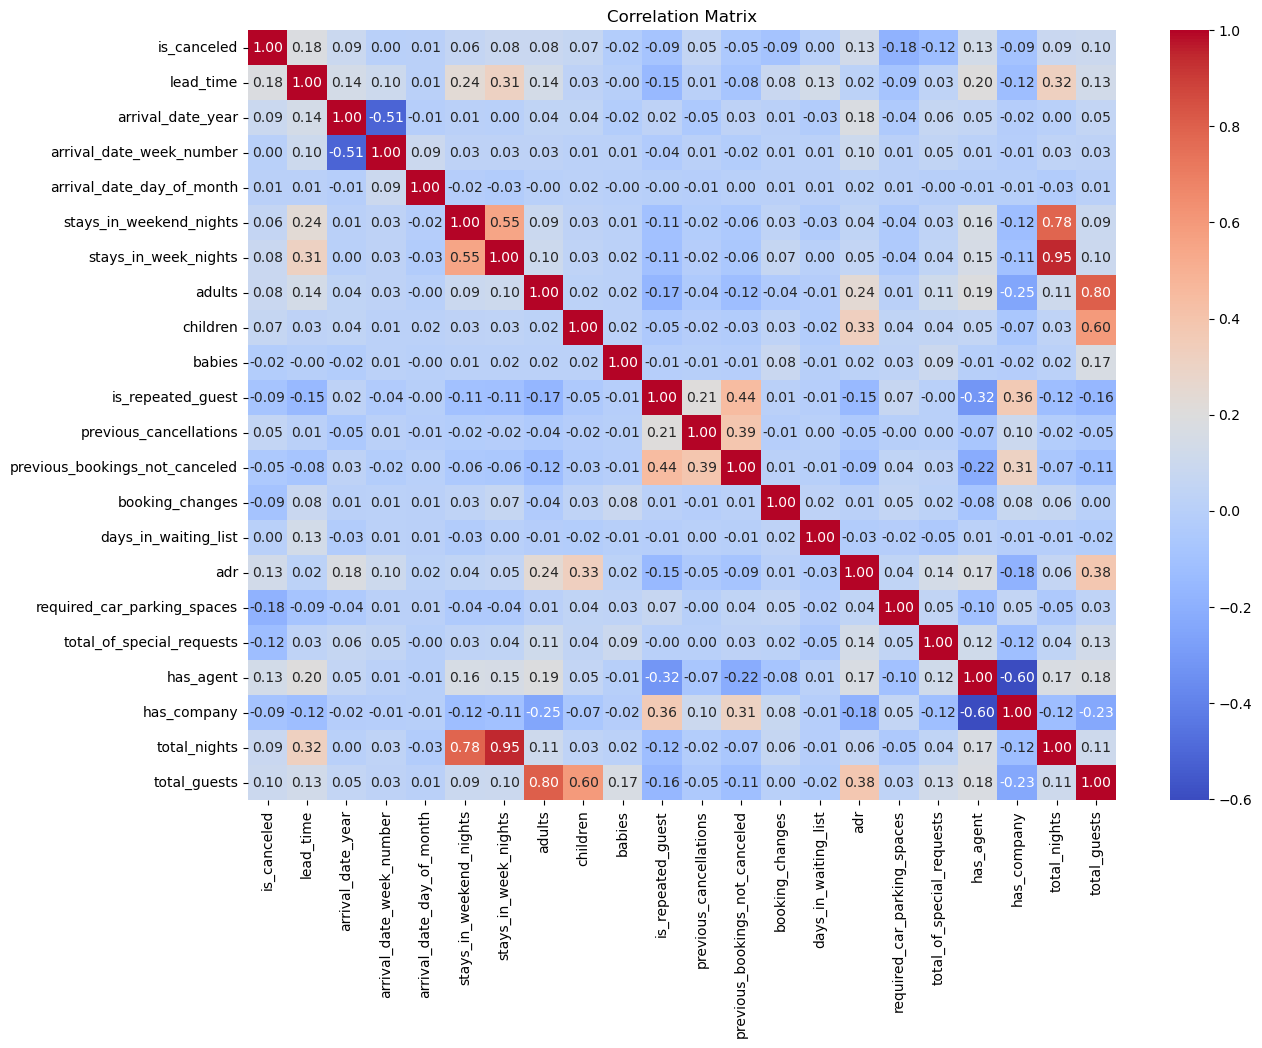

In [209]:
numeric_cols = df.select_dtypes(include="number").columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [210]:
corr_with_target = (
    corr["is_canceled"]
    .sort_values(ascending=False)
)

print(corr_with_target)

is_canceled                       1.000000
lead_time                         0.184428
has_agent                         0.132812
adr                               0.127197
total_guests                      0.098807
arrival_date_year                 0.088065
total_nights                      0.085353
stays_in_week_nights              0.084084
adults                            0.080119
children                          0.067154
stays_in_weekend_nights           0.060934
previous_cancellations            0.051498
arrival_date_day_of_month         0.005406
days_in_waiting_list              0.004702
arrival_date_week_number          0.001594
babies                           -0.020988
previous_bookings_not_canceled   -0.052199
is_repeated_guest                -0.088803
booking_changes                  -0.093281
has_company                      -0.094140
total_of_special_requests        -0.120849
required_car_parking_spaces      -0.184524
Name: is_canceled, dtype: float64


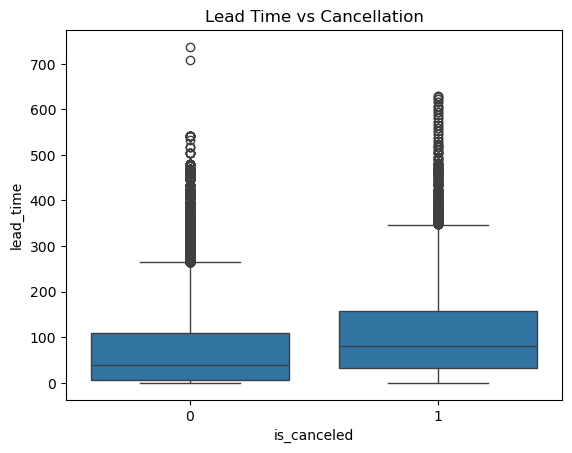

In [211]:
sns.boxplot(x="is_canceled", y="lead_time", data=df)
plt.title("Lead Time vs Cancellation")
plt.show()

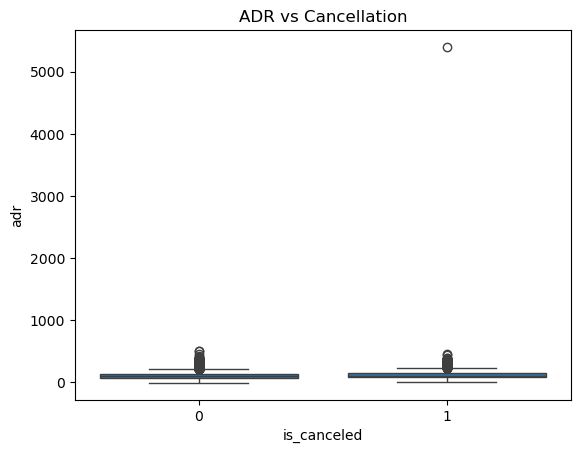

In [212]:
sns.boxplot(x="is_canceled", y="adr", data=df)
plt.title("ADR vs Cancellation")
plt.show()

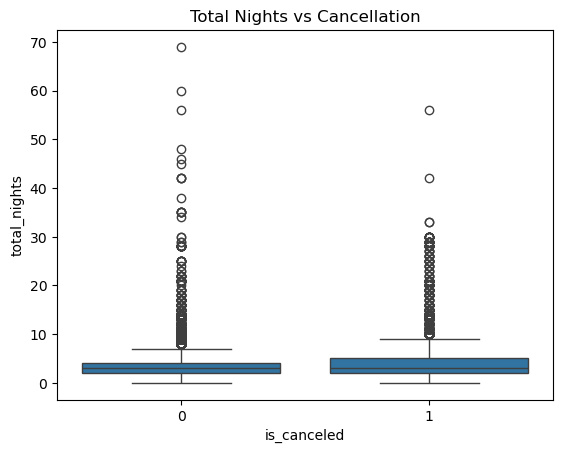

In [213]:
sns.boxplot(x="is_canceled", y="total_nights", data=df)
plt.title("Total Nights vs Cancellation")
plt.show()

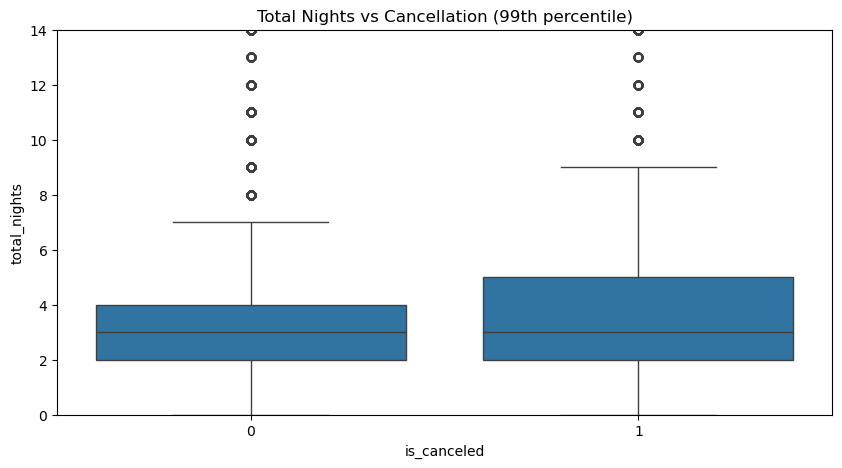

In [214]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="total_nights"
)

plt.ylim(0, df["total_nights"].quantile(0.99))
plt.title("Total Nights vs Cancellation (99th percentile)")
plt.show()


### Encoding

In [216]:
X = df.drop("is_canceled", axis=1)

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical:")
print(list(numeric_features))

print("\nCategorical:")
print(list(categorical_features))

Numerical:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'total_nights', 'total_guests']

Categorical:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


/var/folders/qp/mnlhrt5x2rx27zstwr3s8_200000gp/T/ipykernel_1873/3049401236.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [217]:
X = df.drop(
    columns=[
        "is_canceled",
        "reservation_status",
        "reservation_status_date"
    ]
)

In [218]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

/var/folders/qp/mnlhrt5x2rx27zstwr3s8_200000gp/T/ipykernel_1873/1168470759.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [220]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [221]:
handle_unknown="ignore"

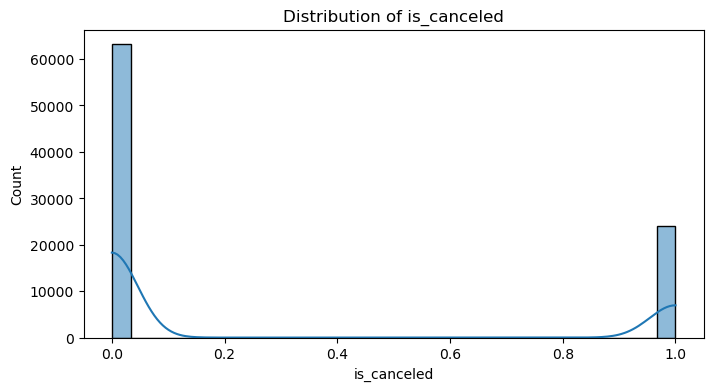

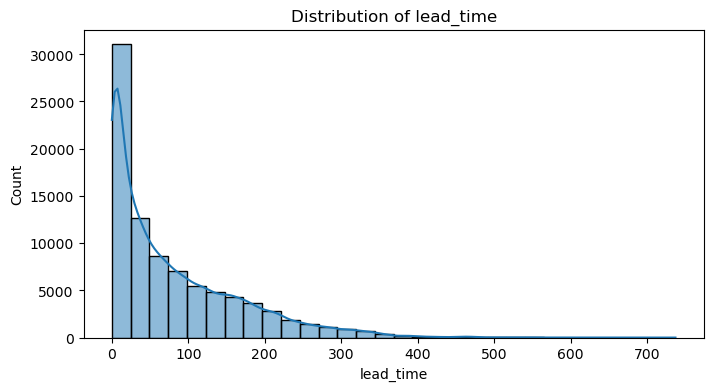

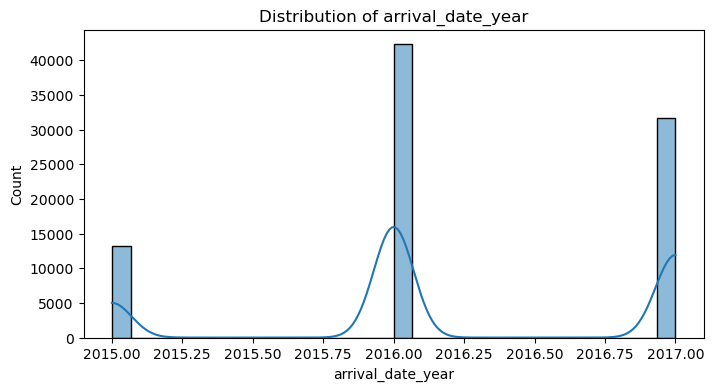

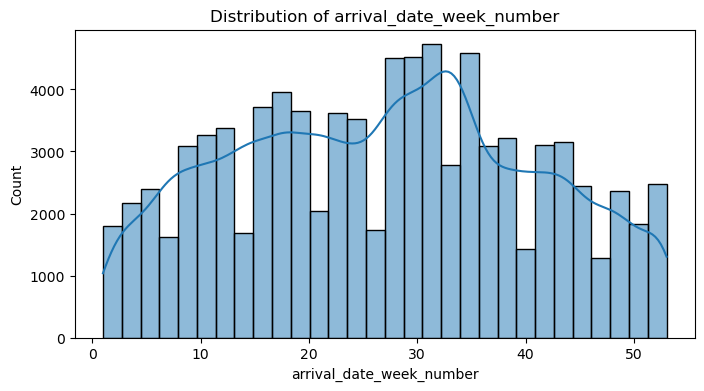

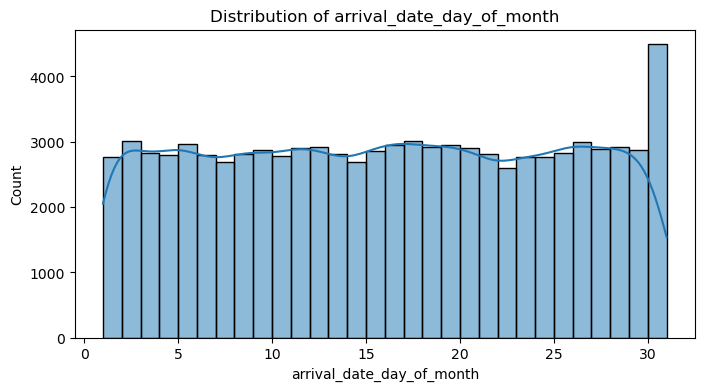

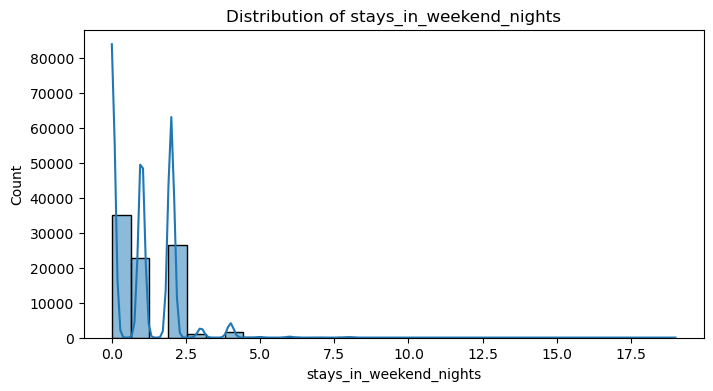

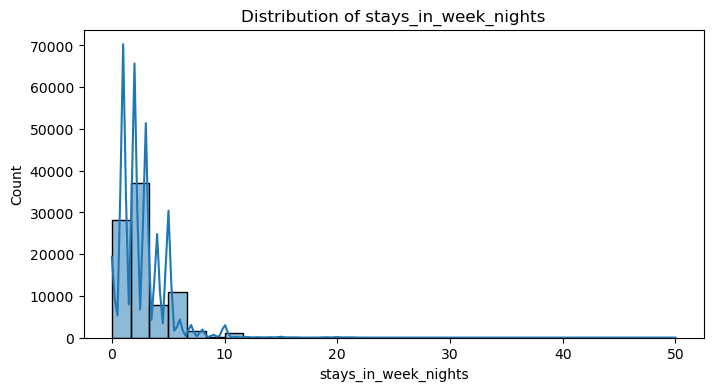

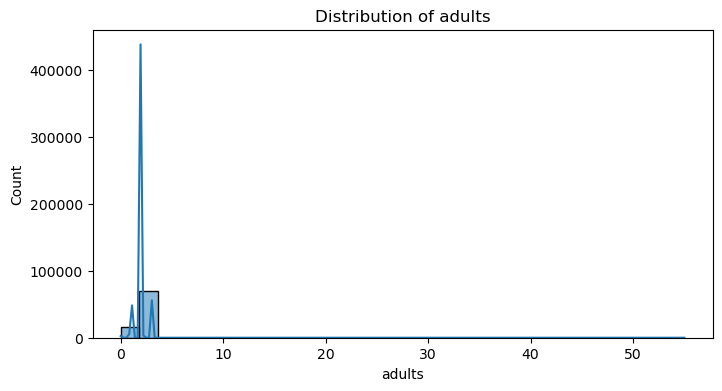

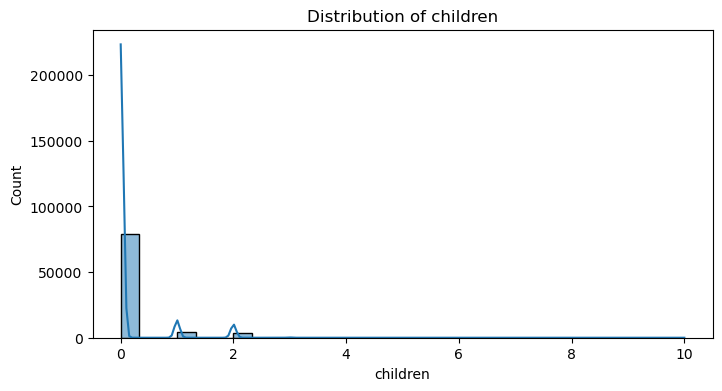

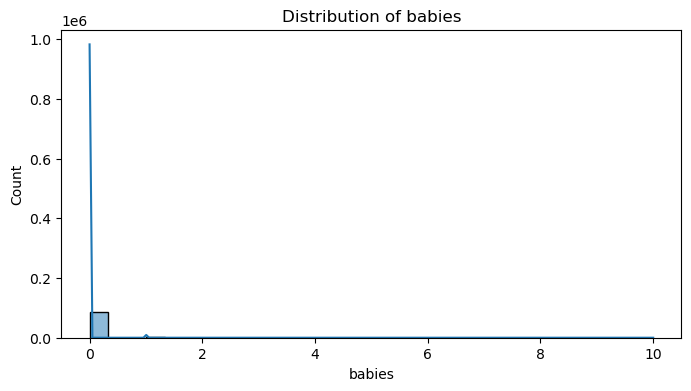

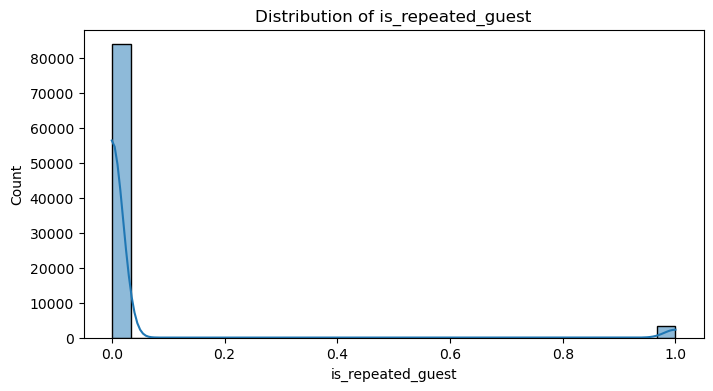

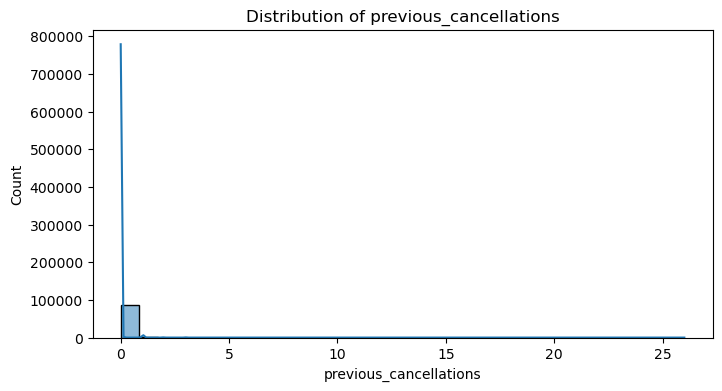

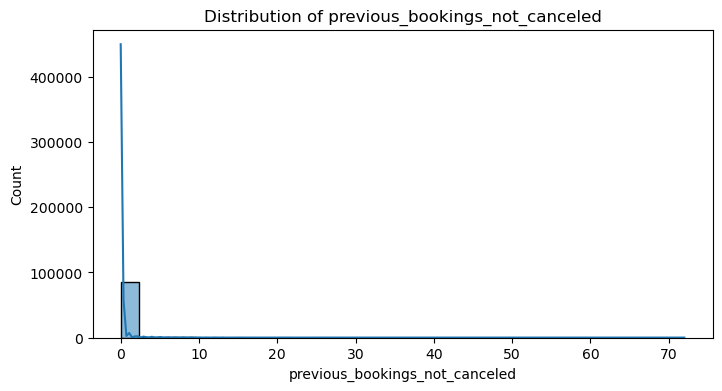

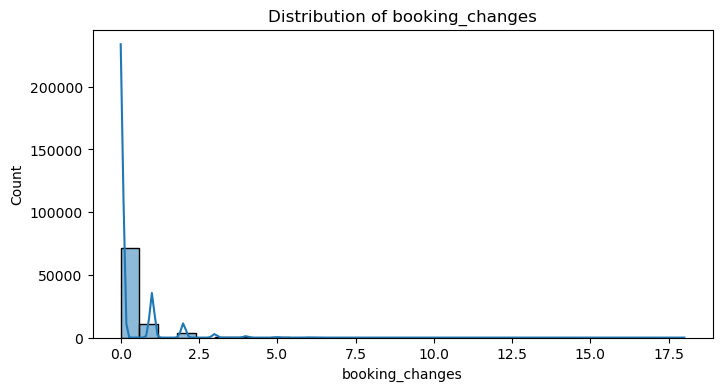

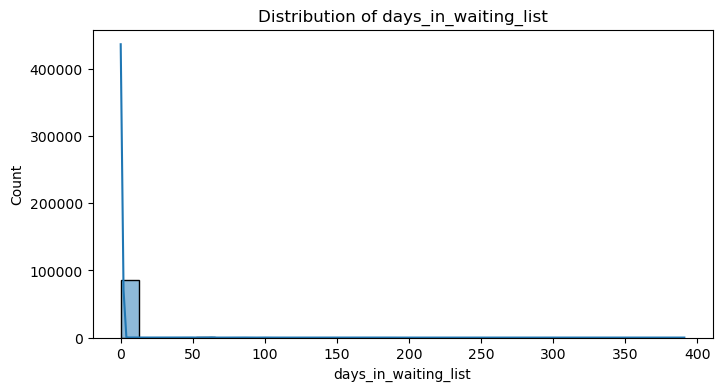

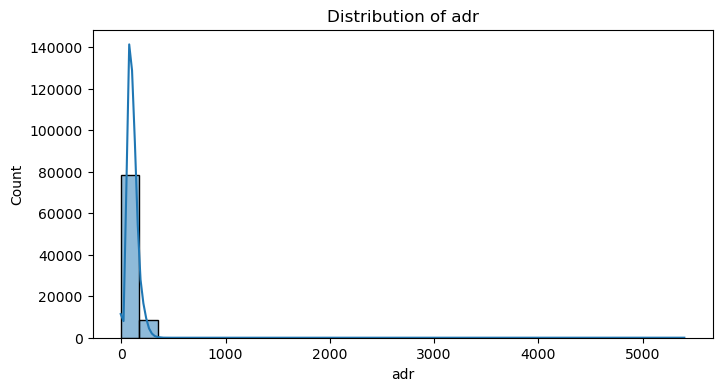

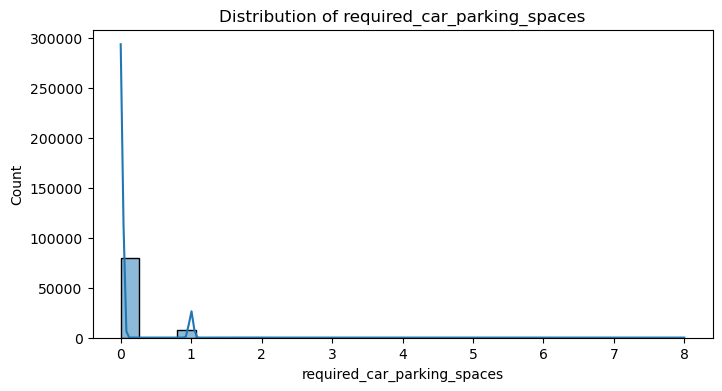

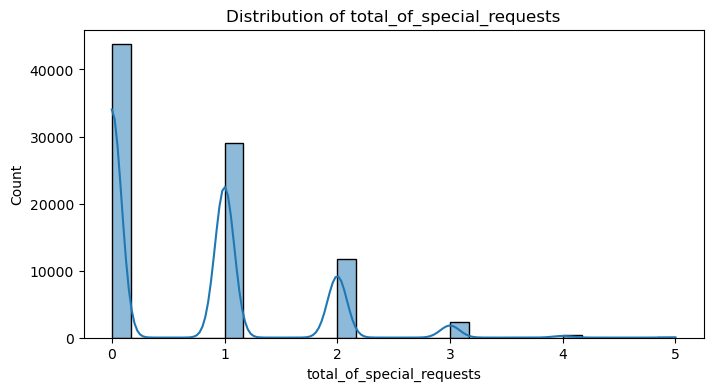

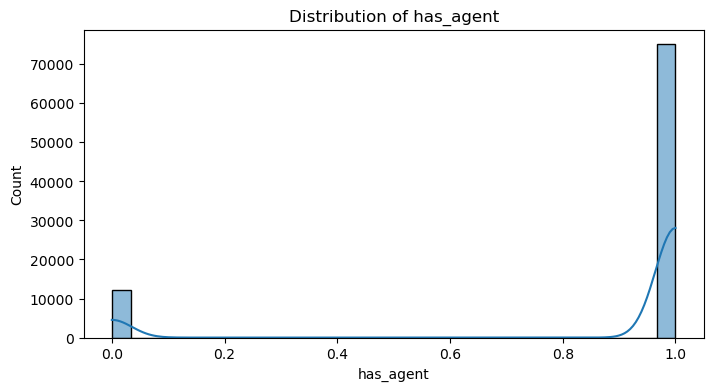

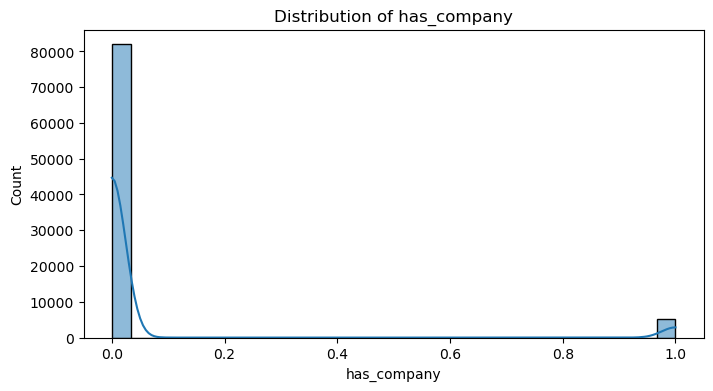

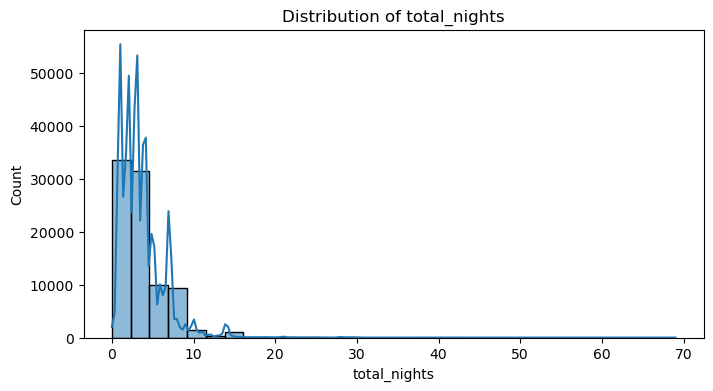

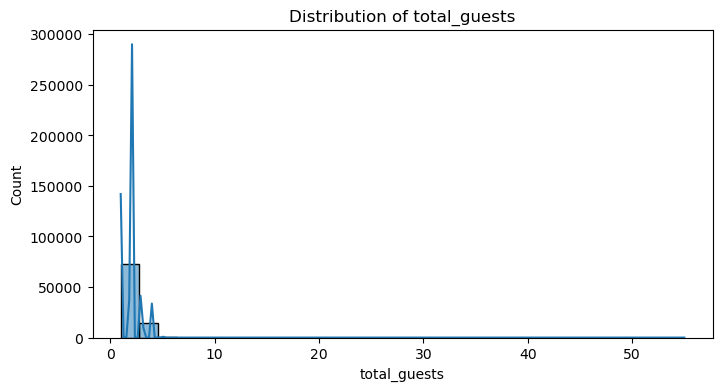

In [223]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [225]:
df["lead_time"] = np.log1p(df["lead_time"])


In [228]:
print(X.columns.tolist())

['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'total_nights', 'total_guests']


In [232]:
X = df.drop(
    columns=[
        "is_canceled",
        "reservation_status",
        "reservation_status_date"
    ],
    errors="ignore"
)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [234]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'total_nights', 'total_guests']
Categorical: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


/var/folders/qp/mnlhrt5x2rx27zstwr3s8_200000gp/T/ipykernel_1873/487976994.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [ ]:


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:


model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [237]:
from sklearn.metrics import accuracy_score, classification_report

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

Accuracy: 80.38%
              precision    recall  f1-score   support

           0       0.83      0.91      0.87     12638
           1       0.69      0.52      0.59      4801

    accuracy                           0.80     17439
   macro avg       0.76      0.72      0.73     17439
weighted avg       0.79      0.80      0.79     17439



In [238]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 0.803830494867825
Accuracy: 80.38%
